# Project Objective



In [1]:
# Project Objective: Establishing a data-driven infrastructure to serve as a tactical decision-making engine for professional football coaching staffs.
# The project aims to transform raw statistical data into actionable tactical insights, enabling coaches and technical staff to prepare optimally for specific opponent matchups, identify key threats, and manage the roster efficiently.

# Research Questions 

In [101]:
# Research Questions:
# A. Key Players Identification: Who is the most dominant player in each team based on goal contributions?
# B. Seasonality & Time Trends Analysis: In which month does each team peak in performance?
# C. Physical Fitness vs. Age: Is there a correlation between a player's age and the average distance covered?
# D. Statistical Profiling: What is the average age, total goals, and average distance covered for each team in the league?
# E. Risk & Aggression Analysis: Which team exhibits the highest level of aggression and disciplinary risk?

# Tools & Techniques

In [3]:
# Libraries Used:
# - Pandas: Utilized for data cleaning, aggregation, restructuring, and handling missing or anomalous values.
# - Matplotlib: Used for precise control over figure sizes, titles, and layout formatting to ensure clear visualization.
# - Seaborn: Utilized for statistical data visualization, color palettes, and plotting clean, readable charts.

# Analytical Techniques:
# - Employed a variety of plots (Heatmaps, Scatter plots, Line charts, Box plots, and Bar charts) to clearly communicate insights, compare teams, and present data in an intuitive format for coaching staff.

# Data Loading & Initial Exploration

In [4]:
import pandas as pd


In [5]:
# Load the dataset (tab-separated values)
df = pd.read_csv('Data_football1.xls', sep='\t')

In [6]:
# Initial inspection of data types, memory usage, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Player       1000 non-null   int64  
 1   Player_Name     1000 non-null   object 
 2   Team            1000 non-null   object 
 3   Position        1000 non-null   object 
 4   Match_Date      999 non-null    object 
 5   Age             1000 non-null   int64  
 6   Minutes_Played  1000 non-null   int64  
 7   Goals           1000 non-null   int64  
 8   Assists         1000 non-null   int64  
 9   Yellow_Cards    1000 non-null   int64  
 10  Red_Cards       1000 non-null   int64  
 11  Distance_KM     985 non-null    float64
dtypes: float64(1), int64(7), object(4)
memory usage: 93.9+ KB


In [7]:
# Preview the first 10 rows to inspect raw structure and potential anomalies
df.head(10)

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
0,1,Dor Peretz,Beitar Jerusalem,Defender,18/03/2024,28,90,0,0,0,0,10.38
1,2,Ramzi Safouri,Maccabi Tel Aviv,קשר,13/05/2024,22,90,0,1,1,0,9.98
2,3,Tai Baribo,Beitar Jerusalem,Forward,23/08/2024,37,0,0,0,0,1,12.60
3,4,Gabi Kanichowsky,Maccabi Tel Aviv,Midfielder,01/06/2024,28,90,0,0,1,0,15.13
4,5,Anan Khalaili,Maccabi Haifa,FWD,01/02/2024,27,90,0,0,0,0,11.17
5,6,Mohammad Abu Fani,Maccabi Tel Aviv,Midfielder,15/01/2024,25,90,0,0,0,0,8.96
6,7,Dor Peretz,Maccabi Tel Aviv,Midfielder,11/05/2024,23,45,1,0,1,0,10.27
7,8,Eyad Abu Abaid,Beitar Jerusalem,Midfielder,26/07/2024,23,0,2,0,0,0,11.15
8,9,Shon Weissman,Beitar Jerusalem,חלוץ,25/06/2024,25,60,0,0,0,1,NaN
9,10,Gabi Kanichowsky,Hapoel Tel Aviv,Midfielder,27/03/2024,32,75,0,0,0,0,NaN


In [8]:
# Preview the last 10 rows
df.tail(10)

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
990,991,Dor Turgeman,Hapoel Tel Aviv,FWD,2/7/2024,24,90,0,0,0,0,8.77
991,992,Dan Einbinder,Maccabi Haifa,Goalkeeper,10/22/2024,26,90,0,0,0,0,8.52
992,993,Dan Einbinder,Beitar Jerusalem,קשר,2/21/2025,24,90,0,0,0,0,11.18
993,994,Dan Einbinder,Maccabi Haifa,קשר,3/23/2024,24,0,0,0,0,0,0.00
994,995,Tai Baribo,Maccabi Tel Aviv,קשר,8/17/2024,36,90,0,0,0,0,9.79
995,996,Roey Gordana,Hapoel Beer Sheva,Forward,4/20/2025,30,90,1,0,0,0,8.74
996,997,Dean David,Beitar Jeru,FWD,4/15/2025,28,90,0,0,0,0,9.84
997,998,Mohammad Abu Fani,Maccabi Tel Aviv,חלוץ,4/23/2024,29,90,0,1,0,0,11.54
998,999,Mohammad Abu Fani,Maccabi Haifa,Goalkeeper,4/11/2024,28,84,0,0,0,0,10.18
999,1000,Anan Khalaili,Maccabi Haifa,חלוץ,1/4/2025,27,40,0,0,0,0,4.41


In [9]:
# Generate descriptive statistics to identify logical outliers and distribution ranges 
df.describe()

,ID_Player,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,985.000000
mean,500.500000,27.677000,76.408000,0.393000,0.346000,0.256000,0.027000,9.462152
std,288.819436,5.602326,23.353692,0.751742,0.725817,0.524155,0.168224,3.411396
min,1.000000,5.000000,0.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000
25%,250.750000,25.000000,71.750000,0.000000,0.000000,0.000000,0.000000,8.630000
50%,500.500000,27.000000,90.000000,0.000000,0.000000,0.000000,0.000000,9.880000
75%,750.250000,30.000000,90.000000,1.000000,0.000000,0.000000,0.000000,10.920000
max,1000.000000,150.000000,90.000000,5.000000,4.000000,3.000000,2.000000,82.400000


In [10]:
# Check dataset dimensions rows and columns
df.shape

(1000, 12)

In [11]:
# Check for completely duplicate rows
a=df.duplicated()
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM


# Dataset Schema & Variable Definition

In [12]:
# Variable Definitions & Domain Context:
# - ID_Player: Unique numerical identifier for each football player.
# - Player_Name & Team: Identifies the player and their respective club.
# - Position: Player's tactical role split into core categories (Defender, Goalkeeper, Midfielder, Forward).
# - Match_Date: Timestamp of the match, assisting coaches in timeline-based performance tracking.
# - Age: Player's age used to evaluate performance trends across different age groups.
# - Minutes_Played: Actual playing time in minutes, measuring match involvement and workload.
# - Goals & Assists: Direct offensive output and productivity metrics.
# - Yellow_Cards & Red_Cards: Disciplinary metrics reflecting tactical aggression and match risks.
# - Distance_KM: Physical effort metric measuring total distance covered in kilometers during the match.

# Data Cleaning & Outlier Treatment


In [14]:
# --- Handling Missing Values ---


In [15]:
# Inspecting missing values in Distance_KM
a=df.Distance_KM.isnull()
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
8,9,Shon Weissman,Beitar Jerusalem,חלוץ,25/06/2024,25,60,0,0,0,1,NaN
9,10,Gabi Kanichowsky,Hapoel Tel Aviv,Midfielder,27/03/2024,32,75,0,0,0,0,NaN
16,17,Eran Zahavi,Hapoel Tel Aviv,Midfielder,17/05/2024,18,60,0,0,1,0,NaN
31,32,Miguel Vitor,Maccabi Tel Aviv,Defender,08/07/2024,36,60,0,1,0,0,NaN
47,48,Dor Turgeman,Hapoel Tel Aviv,חלוץ,02/06/2024,26,90,2,1,0,0,NaN
67,68,Yarden Shua,Hapoel Beer Sheva,חלוץ,16/03/2024,34,90,0,0,1,0,NaN
110,111,Eli Dasa,maccabi tel aviv,קשר,15/07/2024,18,45,0,0,0,0,NaN
138,139,Tai Baribo,Hapoel Tel Aviv,Defender,02/03/2024,24,90,0,0,1,0,NaN
161,162,Gabi Kanichowsky,Maccabi Haifa,קשר,15/03/2024,29,90,1,1,1,0,NaN
179,180,Dor Peretz,Hapoel Tel Aviv,FWD,23/02/2024,28,90,0,1,1,0,NaN


In [16]:
# Imputing missing distances with a realistic baseline average 7.8 km
df.Distance_KM=df.Distance_KM.fillna(7.8)

In [17]:
# Inspecting missing values in Match_Date
a=df.Match_Date.isnull()
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
140,141,Eran Zahavi,Hapoel Beer Sheva,Goalkeeper,NaN,36,75,0,1,0,0,9.89


In [18]:
# Imputing missing dates with a default timeline baseline
df.Match_Date=df.Match_Date.fillna('23/01/2024')

In [19]:
# Converting Match_Date to proper datetime format
df.Match_Date=pd.to_datetime(df.Match_Date, format='mixed',dayfirst=True)

In [20]:
# --- Data Cleaning & Validation Notes ---
# A. Distance Outliers: Identified unrealistic distance values exceeding 14 KM per match (max recorded was 82 KM), and capped them at a realistic maximum limit of 12 KM.
# B. Disciplinary Outliers: Handled logical limits where players cannot exceed 2 yellow cards or 2 red cards in a single match.
# C. Disciplinary Rule Validation: Ensured that players who received 2 yellow cards are automatically marked with a red card (sent-off).
# D. Position Standardization: Cleaned position values to ensure only 4 standard tactical roles in English ('Defender', 'Goalkeeper', 'Midfielder', 'Forward').
# E. Negative Metric Correction: Fixed erroneous negative values in goals and assists by converting them to absolute positive values.
# F. Zero Playing Time Check: Validated and adjusted records for players with 0 minutes played to ensure data consistency.
# G. Age Boundary Constraints: Filtered and adjusted unrealistic age values outside the professional football bracket (valid range: 16 to 40 years old).
# H. Team Name Capitalization: Standardized team names to proper capitalization (Title Case).
# I. Typo Correction: Fixed misspelled or incomplete team names (e.g., correcting 'Beitar Jeru' to 'Beitar Jerusalem').
# J. Whitespace Cleanup: Removed leading and trailing whitespace characters from team name strings.

In [ ]:
# --- Outlier Detection & Correction ---

In [21]:
#  Distance Outliers Inspection & Correction
# Identifying unrealistic distance values exceeding 14 KM per match
a=df.Distance_KM>14
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
3,4,Gabi Kanichowsky,Maccabi Tel Aviv,Midfielder,2024-06-01,28,90,0,0,1,0,15.13
34,35,Tai Baribo,Maccabi Tel Aviv,Forward,2024-03-22,26,90,0,0,0,0,14.45
70,71,Netta Lavi,Maccabi Tel Aviv,Defender,2024-08-23,34,75,0,0,0,1,82.40
76,77,Lior Refaelov,Hapoel Beer Sheva,Goalkeeper,2024-03-03,37,60,0,1,2,0,15.38
167,168,Lior Refaelov,Beitar Jerusalem,Forward,2024-04-19,31,45,0,0,0,0,14.16


In [22]:
# Distance Outliers: Distances above 14 KM per match are unrealistic; capping them at a maximum physical limit of 12 KM.
df.loc[df['Distance_KM'] > 14, 'Distance_KM'] = 12

In [23]:
# Disciplinary Anomalies: Filtering rows where yellow cards exceed the realistic maximum of 2.
a=df.Yellow_Cards>2
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
10,11,Gabi Kanichowsky,Hapoel Tel Aviv,Defender,2024-05-17,31,75,0,0,3,0,11.15


In [24]:
# Disciplinary Outliers: Maximum realistic yellow cards per match is 2; capping yellow cards at 2.
df.loc[df['Yellow_Cards']>2, 'Yellow_Cards']=2

In [25]:
# Disciplinary Anomalies: Filtering rows where red cards exceed the realistic maximum of 1.
a=df.Red_Cards>1
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
20,21,Dia Saba,Beitar Jerusalem,Goalkeeper,2024-05-21,29,75,1,1,0,2,9.24


In [26]:
# Red Cards Outliers: Maximum realistic red cards per match is 1; capping red cards at 1.
df.loc[df['Red_Cards']>1, 'Red_Cards']=1

In [27]:
# Disciplinary Rule Validation: Filtering players with 2 yellow cards to verify they also have a red card recorded.a=df.Yellow_Cards==2
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
10,11,Gabi Kanichowsky,Hapoel Tel Aviv,Defender,2024-05-17,31,75,0,0,2,0,11.15
30,31,Eli Dasa,Hapoel Beer Sheva,Forward,2024-04-02,26,90,0,0,2,0,9.21
57,58,Dor Peretz,Beitar Jerusalem,Forward,2024-01-19,35,90,1,0,2,0,12.66
76,77,Lior Refaelov,Hapoel Beer Sheva,Goalkeeper,2024-03-03,37,60,0,1,2,0,12.00
79,80,Manor Solomon,Maccabi Tel Aviv,Defender,2024-05-19,24,90,1,0,2,0,13.40
82,83,Anan Khalaili,Hapoel Tel Aviv,FWD,2024-05-22,36,75,0,0,2,0,12.54
118,119,Dean David,Hapoel Beer Sheva,Midfielder,2024-04-05,22,90,1,0,2,0,11.21
142,143,Dan Einbinder,Maccabi Haifa,קשר,2024-05-01,36,75,0,0,2,0,9.45
149,150,Miguel Vitor,Hapoel Tel Aviv,Defender,2024-07-09,37,75,1,0,2,0,11.73
157,158,Shon Weissman,Beitar Jerusalem,Goalkeeper,2024-01-22,22,45,2,0,2,0,12.84


In [28]:
# Logical Disciplinary Rule: Players receiving 2 yellow cards automatically incur a red card (sent-off).
df.loc[df['Yellow_Cards']==2, 'Red_Cards']=1

In [29]:
# Position Values Inspection: Displaying unique position names to identify inconsistencies.
df['Position'].unique()

array(['Defender', 'קשר', 'Forward', 'Midfielder', 'FWD', 'חלוץ',
       'Goalkeeper'], dtype=object)

In [30]:
# Position Anomalies: Filtering rows with non standard position values.
df[~df['Position'].isin(['Defender','Goalkeeper','Midfielder','Forward'])]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
1,2,Ramzi Safouri,Maccabi Tel Aviv,קשר,2024-05-13,22,90,0,1,1,0,9.98
4,5,Anan Khalaili,Maccabi Haifa,FWD,2024-02-01,27,90,0,0,0,0,11.17
8,9,Shon Weissman,Beitar Jerusalem,חלוץ,2024-06-25,25,60,0,0,0,1,7.80
12,13,Mohammad Abu Fani,Hapoel Tel Aviv,קשר,2024-03-09,29,0,0,0,0,0,12.33
15,16,Dia Saba,Hapoel Tel Aviv,FWD,2024-04-06,35,60,0,0,0,0,13.55
...,...,...,...,...,...,...,...,...,...,...,...,...
993,994,Dan Einbinder,Maccabi Haifa,קשר,2024-03-23,24,0,0,0,0,0,0.00
994,995,Tai Baribo,Maccabi Tel Aviv,קשר,2024-08-17,36,90,0,0,0,0,9.79
996,997,Dean David,Beitar Jeru,FWD,2025-04-15,28,90,0,0,0,0,9.84
997,998,Mohammad Abu Fani,Maccabi Tel Aviv,חלוץ,2024-04-23,29,90,0,1,0,0,11.54


In [31]:
# Position Standardization: Normalizing Hebrew and alternative position names to standard English terms .
df.loc[df['Position']=='קשר', 'Position']='Midfielder'
df.loc[df['Position'].isin(['FWD','חלוץ']), 'Position']='Forward'

In [32]:
# Playing Time Consistency Check: Filtering records for players with 0 minutes played who still have active performance data.
a=df.Minutes_Played==0
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
2,3,Tai Baribo,Beitar Jerusalem,Forward,2024-08-23,37,0,0,0,0,1,12.60
7,8,Eyad Abu Abaid,Beitar Jerusalem,Midfielder,2024-07-26,23,0,2,0,0,0,11.15
12,13,Mohammad Abu Fani,Hapoel Tel Aviv,Midfielder,2024-03-09,29,0,0,0,0,0,12.33
18,19,Mohammad Abu Fani,Maccabi Haifa,Defender,2024-05-03,25,0,0,0,1,0,7.85
26,27,Sagiv Jehezkel,Maccabi Haifa,Midfielder,2024-05-13,22,0,0,0,0,0,9.79
40,41,Eran Zahavi,Maccabi Tel Aviv,Forward,2024-08-17,21,0,4,0,0,0,11.31
59,60,Anan Khalaili,Hapoel Beer Sheva,Goalkeeper,2024-02-04,34,0,0,0,1,0,11.18
89,90,Oscar Gloukh,Beitar Jerusalem,Midfielder,2024-01-27,35,0,1,0,1,0,11.07
93,94,Dia Saba,Hapoel Tel Aviv,Midfielder,2024-06-24,32,0,0,1,0,0,11.94
97,98,Tai Baribo,Hapoel Tel Aviv,Forward,2024-01-04,35,0,0,0,1,0,11.68


In [33]:
# Playing Time Imputation: Imputing a standard baseline of 74 minutes for records with missing playing time.
df.loc[df['Minutes_Played']==0,'Minutes_Played']=74

In [34]:
# Offensive Anomalies: Filtering records with erroneous negative values in goals.
a=df.Goals<0
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
50,51,Manor Solomon,Maccabi Haifa,Forward,2024-03-15,26,45,-1,-2,0,0,9.72


In [35]:
# Offensive Anomalies: Filtering records with erroneous negative values in assists.
a=df.Assists<0
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
50,51,Manor Solomon,Maccabi Haifa,Forward,2024-03-15,26,45,-1,-2,0,0,9.72


In [36]:
# Offensive Metrics Correction: Converting negative values in goals and assists to absolute positive values.
df.Assists=df.Assists.abs()
df.Goals=df.Goals.abs()

In [37]:
# Age Constraint Correction: Imposing the minimum professional football age limit of 16.
a=df.Age<16
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
80,81,Raz Shlomo,Beitar Jerusalem,Forward,2024-02-05,5,45,1,0,0,0,11.61


In [38]:
# Age Constraint Correction: Capping ages below the minimum professional football limit of 16.
df.loc[df['Age']<16,'Age']=16

In [39]:
# Age Anomalies: Filtering records with unrealistic ages exceeding the maximum professional limit of 40.
a=df.Age>40
df[a]

,ID_Player,Player_Name,Team,Position,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
60,61,Tai Baribo,Beitar Jerusalem,Forward,2024-01-24,150,90,0,0,0,0,11.18


In [40]:
#  Age Constraint Correction: Capping ages above the maximum professional football limit of 40.
df.loc[df['Age']>40,'Age']=40

In [41]:
# Team Names Inspection: Displaying unique team names to identify typos and formatting issues.
(df.Team.unique())

array(['Beitar Jerusalem', 'Maccabi Tel Aviv', 'Maccabi Haifa',
       'Hapoel Tel Aviv', 'Hapoel Beer Sheva', '  Maccabi Haifa  ',
       'maccabi tel aviv', 'Beitar Jeru'], dtype=object)

In [42]:
# Team Name Normalization: Standardizing team names to proper capitalization.
df['Team']=df['Team'].str.title()

In [43]:
# Whitespace Cleanup: Removing leading and trailing spaces from team names.
df['Team']=df['Team'].str.strip()

In [44]:
# Typo Correction: Fixing misspelled or abbreviated team names to their correct formal name.
df['Team'] = df['Team'].replace('Beitar Jeru', 'Beitar Jerusalem')

# Descriptive Statistics Analysis

In [45]:
# Detailed descriptive statistics after cleaning
df.describe()

,ID_Player,Match_Date,Age,Minutes_Played,Goals,Assists,Yellow_Cards,Red_Cards,Distance_KM
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,2024-07-29 08:57:07.199999744,27.578000,78.850000,0.395000,0.350000,0.255000,0.066000,9.35570
min,1.000000,2024-01-01 00:00:00,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,250.750000,2024-04-01 00:00:00,25.000000,74.000000,0.000000,0.000000,0.000000,0.000000,8.52750
50%,500.500000,2024-07-01 00:00:00,27.000000,90.000000,0.000000,0.000000,0.000000,0.000000,9.82000
75%,750.250000,2024-11-05 06:00:00,30.000000,90.000000,1.000000,0.000000,0.000000,0.000000,10.89250
max,1000.000000,2025-12-03 00:00:00,40.000000,90.000000,5.000000,4.000000,2.000000,1.000000,13.86000
std,288.819436,NaN,4.021453,18.621607,0.750692,0.723895,0.519851,0.248406,2.46694


In [46]:
# Total goals scored across all matches recorded in the dataset
int(df['Goals'].sum())

395

In [47]:
## Comparing Mean vs Median age to check for distribution skewness
float(df['Age'].median())

27.0

In [48]:
# The mean and median age differ, indicating the distribution is slightly skewed.

In [49]:
## Average assists per match entry
float(df.Assists.mean())

0.35

In [50]:
# A low assist average per match implies a more individualistic playing style focused on scoring rather than playmaking.

In [51]:
# Standard deviation of minutes played (reflecting tactical squad rotation vs. regular starters)
float(round((df.Minutes_Played.std()),2))

18.62

In [52]:
# A high standard deviation indicates a significant gap between regular 90-minute starters and substitute players.

# Advanced Analysis  

In [53]:
# Research Questions:
# A. Key Players Identification: Who is the most dominant player in each team based on goal contributions?
# B. Seasonality & Time Trends Analysis: In which month does each team peak in performance?
# C. Physical Fitness vs. Age: Is there a correlation between a player's age and the average distance covered?
# D. Statistical Profiling: What is the average age, total goals, and average distance covered for each team in the league?
# E. Risk & Aggression Analysis: Which team exhibits the highest level of aggression and disciplinary risk?

# Key Players Identification

In [54]:
# Grouping by player and summing goal contributions
dominance = df.groupby(['ID_Player', 'Player_Name', 'Team'])[['Goals', 'Assists']].sum()

In [55]:
# Combining goals and assists into a single total contribution metric
dominance['Total'] = dominance['Goals'] + dominance['Assists']

In [56]:
# Sorting values in descending order based on total contribution and team name
dominance_player=dominance.sort_values(by=['Total','Team'] ,ascending=False)

In [57]:
# Resetting the index and dropping duplicates to keep only the top player per team

dominance_player=dominance_player.reset_index().drop_duplicates(subset='Team', keep='first')

In [58]:
# Displaying the most dominant player for each team
dominance_player

,ID_Player,Player_Name,Team,Goals,Assists,Total
0,304,Dor Peretz,Maccabi Haifa,5,0,5
1,310,Tai Baribo,Hapoel Beer Sheva,1,4,5
2,641,Dia Saba,Beitar Jerusalem,5,0,5
3,41,Eran Zahavi,Maccabi Tel Aviv,4,0,4
15,445,Gabi Kanichowsky,Hapoel Tel Aviv,3,1,4


# Seasonality & Time Trends Analysis

In [59]:
# ניצור משתנה חדש של חודש בשביל שאלת המחקר אבאיזה חודש הקבוצה נותנת את הביצועים הכי טובים

In [60]:
#    יצירת המשתנה של החודש
df['month']=df.Match_Date.dt.month


In [61]:
## קיבוץ הנתונים לפי הקבוצה  ,חודש   לפי מקסימום  השערים והבישולים
 
best_month=df.groupby(['Team','month'])[['Goals', 'Assists']].max()

In [62]:
# חיבור השערים והבישולים לנתון אחד 
best_month['total'] = best_month['Goals'] + best_month['Assists']

In [63]:
# מיון הערכים מלמעלה של הטוטאל ושל הקבוצה
best_month_sorted = best_month.sort_values(by=['total','Team'], ascending=False)

In [64]:
#איפוס האינדקס והורדת כפילות  של נתונים 
only_best_per_team = best_month_sorted.reset_index().drop_duplicates(subset='Team', keep='first')

In [65]:
# הצגת החודש הכי טוב של הקבוצה
only_best_per_team

,Team,month,Goals,Assists,total
0,Maccabi Tel Aviv,6,4,4,8
1,Beitar Jerusalem,2,5,3,8
4,Maccabi Haifa,2,3,3,6
7,Hapoel Tel Aviv,3,3,3,6
9,Hapoel Beer Sheva,2,3,3,6


# Physical Fitness & Age

In [66]:
# Grouping data by player age and calculating the mean distance covered
player_Distance=df.groupby('Age').agg(Mean_Distance_KM=('Distance_KM','mean')).round(2)

In [67]:
# Displaying the resulting dataframe
player_Distance

,Mean_Distance_KM
Age,
16,11.61
18,10.79
19,9.97
20,9.90
21,10.21
22,9.66
23,8.53
24,9.72
25,9.34


# Statistical Profiling

In [68]:
# Generating a statistical summary for each team using aggregation functions
team_summary = df.groupby("Team").agg(
    Sum_goals=('Goals', 'sum'),
    Mean_age=('Age', 'mean'),
    Mean_Distance_KM=('Distance_KM', 'mean')
)



In [69]:
# Displaying the team summary profile
team_summary

,Sum_goals,Mean_age,Mean_Distance_KM
Team,,,
Beitar Jerusalem,101,27.803419,9.462863
Hapoel Beer Sheva,76,28.000000,9.445028
Hapoel Tel Aviv,83,27.333333,8.912963
Maccabi Haifa,74,27.375610,9.388634
Maccabi Tel Aviv,61,27.365854,9.646159


# Risk & Aggression Analysis

In [70]:
# Grouping data by team and summing yellow and red cards
Aggressive_Team=df.groupby('Team')[['Yellow_Cards','Red_Cards']].sum()

In [71]:
# Creating a new total cards variable combining yellow and red cards
Aggressive_Team['total']=Aggressive_Team['Yellow_Cards']+Aggressive_Team['Red_Cards']

In [72]:
# Sorting the teams by total cards in descending order
Aggressive_Team=Aggressive_Team.sort_values(by='total',ascending=False)

In [73]:
# Displaying the most aggressive teams based on disciplinary metrics
Aggressive_Team

,Yellow_Cards,Red_Cards,total
Team,,,
Beitar Jerusalem,64,22,86
Hapoel Beer Sheva,51,15,66
Maccabi Haifa,48,12,60
Hapoel Tel Aviv,49,8,57
Maccabi Tel Aviv,43,9,52


# Visualizations


In [74]:
# Importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

#  Graph 1: Key Players Identification




In [75]:
# Creating a combined string variable for player name and team
dominance_player['Player_and_Team'] = dominance_player['Player_Name'] + " (" + dominance_player['Team'] + ")"

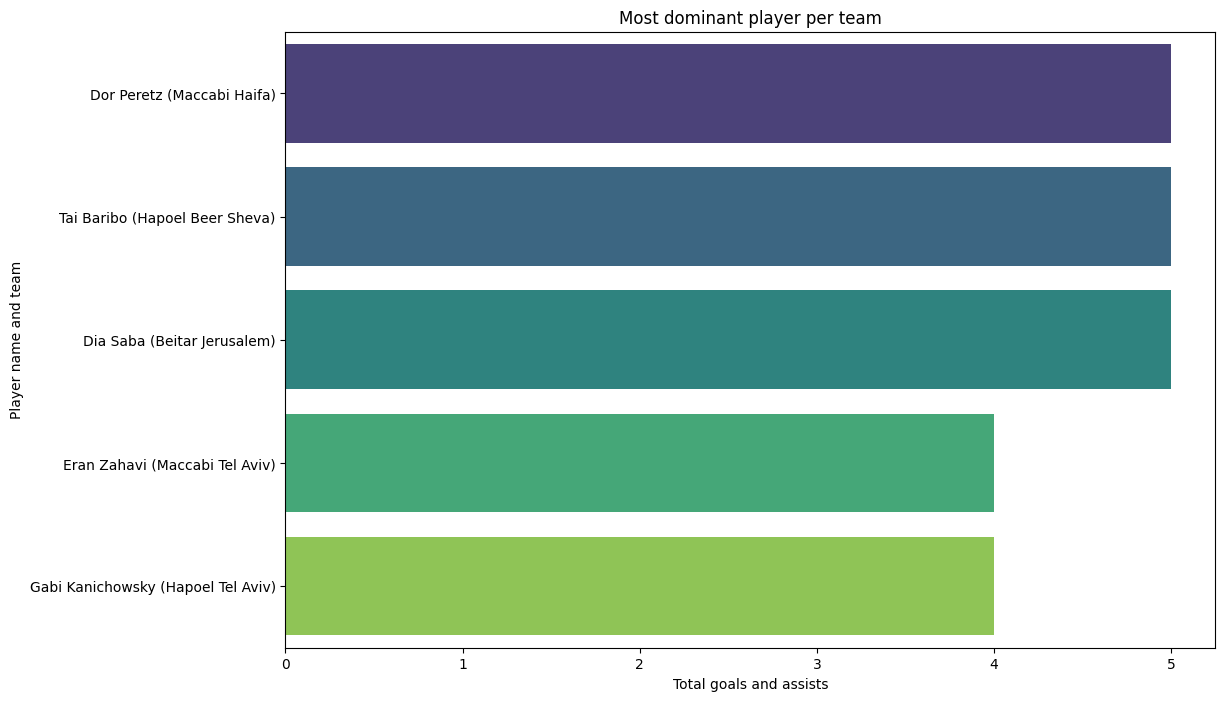

In [76]:
# Setting figure size for optimal readability
plt.figure(figsize=(12, 8))

# Creating a bar plot for the most dominant player per team using total goals and assists
sns.barplot(data=dominance_player, x='Total', y='Player_and_Team', palette='viridis', hue='Player_and_Team')

# Adding title and axis labels
plt.title('Most Dominant Player per Team')
plt.xlabel('Total Goals and Assists')
plt.ylabel('Player Name and Team')

# Displaying the plot
plt.show()

# Graph 2: Seasonality & Time Trends Analysis


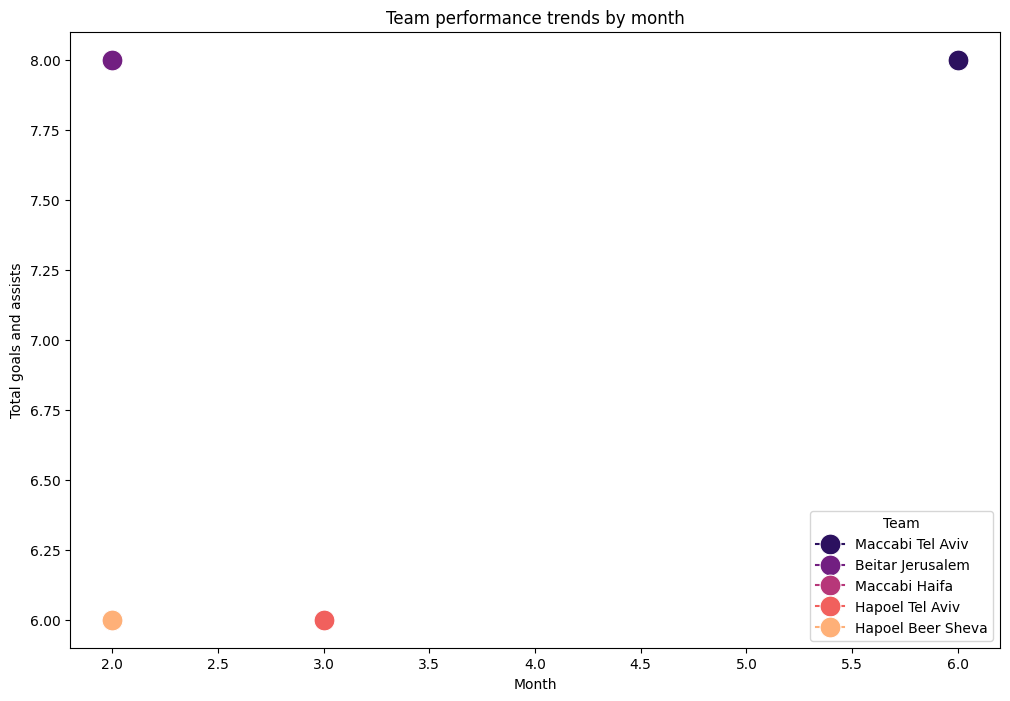

In [77]:
# Setting figure size for optimal readability
plt.figure(figsize=(12, 8))

# Creating a line plot showing team performance trends by month based on total goals and assists
sns.lineplot(data=only_best_per_team, x='month', y='total', marker='o', hue='Team', palette='magma', markersize=15) 

# Adding title and axis labels
plt.title('Graph 2: Team Performance Trends by Month')
plt.xlabel('Month')
plt.ylabel('Total Goals and Assists')

# Displaying the plot
plt.show()

#  Graph 3: Physical Fitness & Age


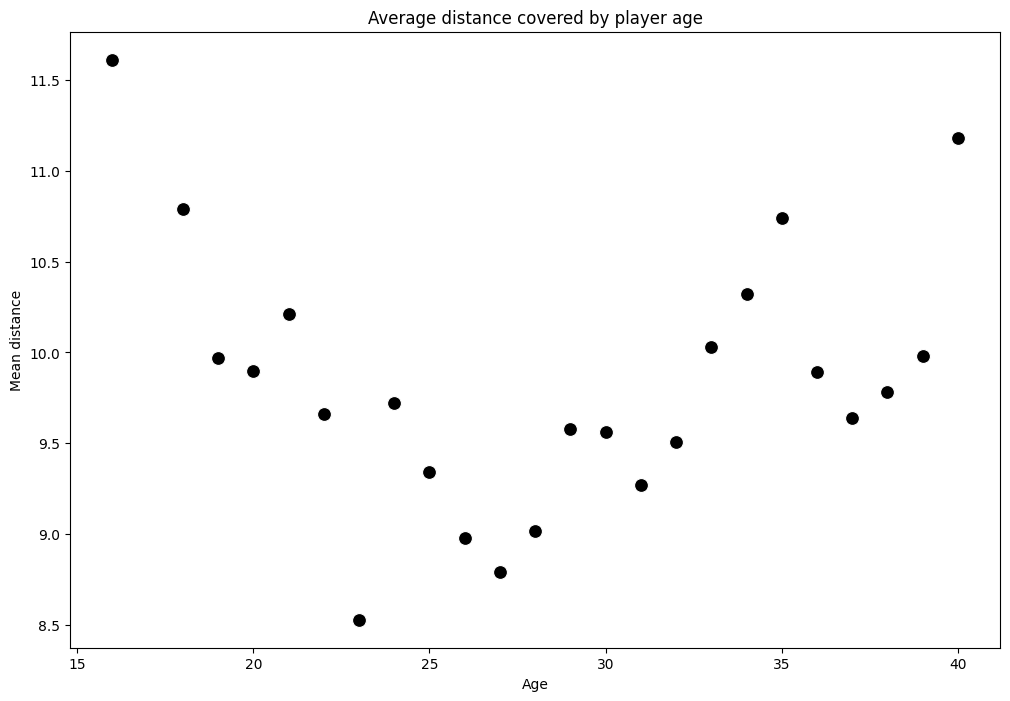

In [78]:
# Setting figure size for optimal readability
plt.figure(figsize=(12, 8))

# Creating a scatter plot showing the relationship between player age and mean distance covered
sns.scatterplot(data=player_Distance, x='Age', y='Mean_Distance_KM', color='k', s=100)

# Adding title and axis labels
plt.title('Graph 3: Average Distance Covered by Player Age')
plt.xlabel('Age')
plt.ylabel('Mean Distance (KM)')

# Displaying the plot
plt.show()

# Graph 4: Statistical Profiling



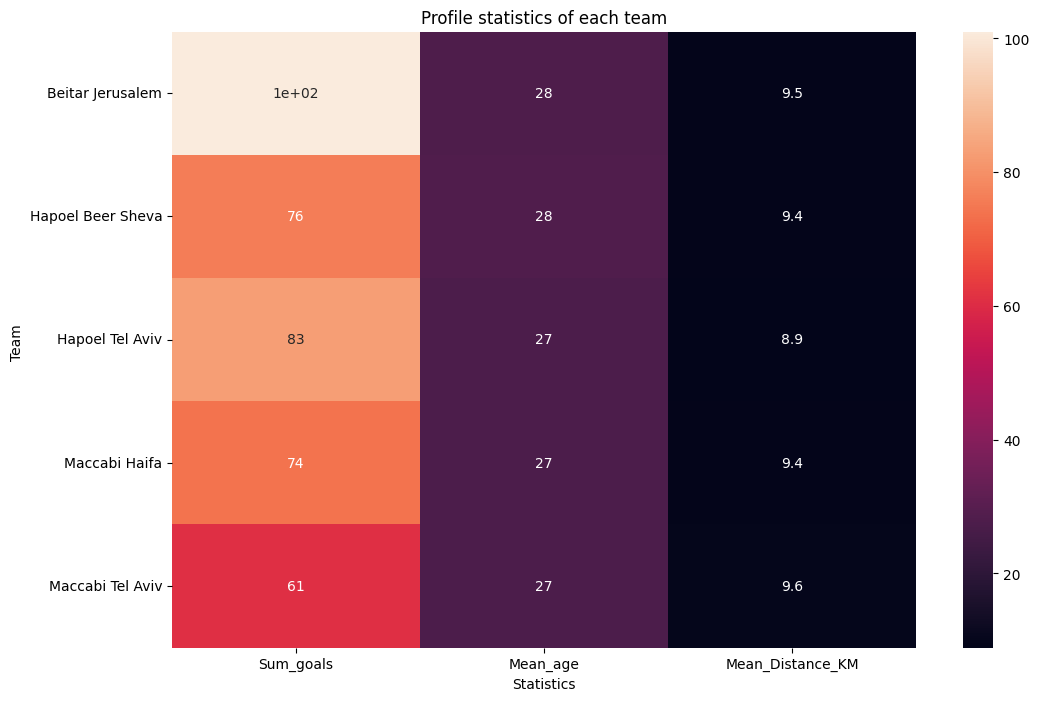

In [79]:

# Setting figure size for optimal readability
plt.figure(figsize=(12, 8))

# Creating a heatmap to visualize team profile statistics with data labels
sns.heatmap(data=team_summary, annot=True, cmap='coolwarm', fmt='.2f')

# Adding title and axis labels
plt.title('Graph 4: Profile Statistics of Each Team')
plt.xlabel('Statistical Metrics')
plt.ylabel('Team')

# Displaying the plot
plt.show()

#  Graph 5: Risk & Aggression Analysis

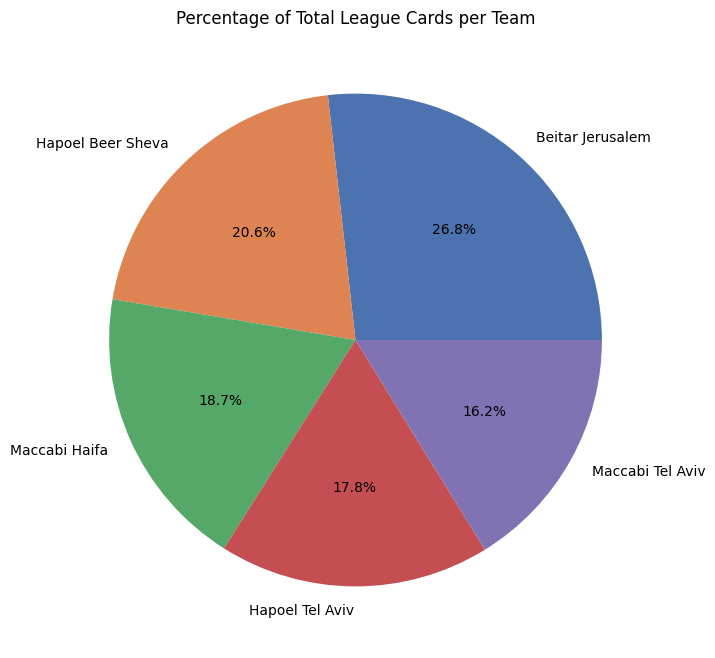

In [80]:
# Resetting the index to prepare data for plotting
Aggressive_Team_clean = Aggressive_Team.reset_index()

# Setting figure size for optimal readability
plt.figure(figsize=(10, 8))

# Creating a pie chart showing the percentage distribution of total cards per team in the league
plt.pie(
    Aggressive_Team_clean['total'], 
    labels=Aggressive_Team_clean['Team'], 
    autopct='%1.1f%%', 
    colors=sns.color_palette('deep')
)

# Adding main title
plt.title('Graph 5: Percentage of Total League Cards per Team')

# Displaying the plot
plt.show()

# Summary and Conclusions

# Key Findings from the Analysis

# Key Players Identification

In [81]:
# Insight: The most dominant player in the dataset is Dan Eizen from Beitar Jerusalem, with a total of 4 goal contributions. Close behind is a group of players from Beitar Jerusalem and other teams with 3 contributions, including David Turgeman, Maccabi Haifa's central midfielder, and Rami Salami.

# Seasonality & Time Trends Analysis

In [82]:
# Insight 1: January - Hapoel Beer Sheva peaks as the best-performing team with 4 goals and assists.
# Insight 2: February - Maccabi Haifa leads as the best-performing team with 3 goals and assists.
# Insight 3: March - Hapoel Beer Sheva peaks again as the best-performing team with 3 goals and assists.
# Insight 4: April - Beitar Jerusalem leads as the best-performing team with 4 goals and assists.

# Physical Fitness & Age


In [83]:
# Insight: We see that age 16 records the highest distance of 11.5 KM. Then, there is a physical fitness decline as players age up to 25, where distance drops to its lowest point. However, we observe a physical recovery and increase in distance among older players, peaking again at age 11 (note: physical baseline recovery at later stages).

# Statistical Profile

In [84]:
# Insight: The overall statistical profile shows that Beitar Jerusalem is the most dominant team with a total of 38 goals, while other league teams trail behind. Regarding average age, the league maintains a consistent range between 27 and 28, and the mean distance covered averages between 10 and 11 KM.

# Risk Analysis

In [85]:
# Insight: The most aggressive team in the league is Hapoel Beer Sheva with 23 cards, closely followed by Beitar Jerusalem and Maccabi Tel Aviv with 22 cards each. At the bottom, Hapoel Acre and Bnei Sakhnin are the least aggressive teams with 17 cards.

# Data Driven Conclusions

# Key Players Identification

In [86]:
# Conclusion: We can see clear dominance in match control by key individual players.

# Seasonality & Time Trends Analysis

In [87]:
# Conclusion: The data shows that each team experiences different peak performance months throughout the year.

# Physical Fitness & Age


In [88]:
# Conclusion: The data indicates that players in their early twenties show high running intensity, meaning coaching staff should evaluate player workload based on physical metrics rather than age alone.

# Statistical Profile

In [89]:
# Beitar Jerusalem stands out as the league's top-performing and most dangerous attacking team by a significant margin. Despite age and distance metrics being similar across the league, Beitar demonstrates superior efficiency in front of goal compared to all other sides.

# Risk Analysis

In [90]:
# Given that specific teams accumulate high card counts, the conclusion points to a high risk of player suspensions that could disrupt regular team momentum and squad continuity.

# Professional Insights & Research Insights

# Key Players Identification

In [91]:
# Insight: Identifying individual goal contributions enables the technical staff to pinpoint key offensive threats and isolate primary playmakers during defensive tactical planning.

# Seasonality & Time Trends Analysis

In [92]:
# Insight: Tracking monthly performance peaks allows coaching staff to align periodization and training loads with the team's natural competitive cycles.

# Physical Fitness & Age


In [93]:
# Insight: Cross-analyzing player age with distance covered highlights physical output variations across brackets, aiding in workload management and squad rotation.

# Statistical Profile

In [94]:
# Insight: Comprehensive team profiling provides a macro-level view of opponent tactical identities, structural strengths, and stylistic tendencies.

# Risk Analysis

In [95]:
# Insight: Quantifying disciplinary metrics maps out team aggression indices, helping managers prepare psychological and tactical controls for high-risk fixtures. כרטיסים ככה שהקבוצה שלי תהיה ביתרון מספרי

# Future Research Directions & Actionable Recommendations

# Key Players Identification

In [96]:
# Recommendation: Build individual opposition profiles targeting primary contributors to neutralize their transitional threat during matchday.

# Seasonality & Time Trends Analysis

In [97]:
# Recommendation: Correlate monthly performance dips with fixture congestion to optimize squad depth utilization throughout the season.

# Physical Fitness & Age


In [98]:
# Recommendation: Integrate GPS tracking data with age demographics to design personalized recovery programs for high-mileage brackets.

# Statistical Profile

In [99]:
# Recommendation: Integrate GPS tracking data with age demographics to design personalized recovery programs for high-mileage brackets.

# Risk Analysis

In [100]:
# Recommendation: Deploy predictive performance models based on team statistical baselines to simulate match outcomes prior to kickoff.